In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "/input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv
/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv
/kaggle/input/models/muhammadsafeer12348/multi-class-bert-news-classifier/pytorch/default/1/config.json
/kaggle/input/models/muhammadsafeer12348/multi-class-bert-news-classifier/pytorch/default/1/model.safetensors


# Imports

In [5]:
import os
import random
import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Load and Preprocess Data

In [6]:
DATA_PATH = "/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/"

train_df = pd.read_csv(DATA_PATH + "train.csv")
test_df  = pd.read_csv(DATA_PATH + "test.csv")

print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (120000, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


## Check for Nulls

In [7]:
print(f"\nNull values: {train_df.isnull().sum()},\n\n{test_df.isnull().sum()}")


Null values: Class Index    0
Title          0
Description    0
dtype: int64,

Class Index    0
Title          0
Description    0
dtype: int64


## Check Duplicates

In [8]:
print("Duplicate rows:", train_df.duplicated().sum(), test_df.duplicated().sum())

Duplicate rows: 0 0


## Concatenate Title + Description

In [9]:
train_df["text"] = train_df["Title"] + " [SEP] " + train_df["Description"]
test_df["text"] = test_df["Title"] + " [SEP] " + test_df["Description"]

train_df.head()

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


## Check and Correct Length for GPU Efficiency

In [10]:
train_df["word_len"] = train_df["Description"].str.split().apply(len)
print(train_df["word_len"].describe())

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: word_len, dtype: float64


In [11]:
train_df[train_df["word_len"] <= 3 ]

,Class Index,Title,Description,text,word_len
17812,2,Sabres agree to terms with 2003 first-round pi...,#NAME?,Sabres agree to terms with 2003 first-round pi...,1
21983,4,Intel looks to fend off AMD with new 2006 chipset,&lt;strong&gt;Exclusive&lt;/strong&gt; Blackfo...,Intel looks to fend off AMD with new 2006 chip...,3
22955,2,Top of 3rd,#NAME?,Top of 3rd [SEP] #NAME?,1
23969,2,"Blues re-sign D Backman, four others",#NAME?,"Blues re-sign D Backman, four others [SEP] #NAME?",1
27805,2,Wild re-sign D Schultz,#NAME?,Wild re-sign D Schultz [SEP] #NAME?,1
27806,2,"Blue Jackets re-signs G Denis, RW Vyborny",#NAME?,"Blue Jackets re-signs G Denis, RW Vyborny [SEP...",1
29104,2,Predators re-sign D Zidlicky,#NAME?,Predators re-sign D Zidlicky [SEP] #NAME?,1
38557,4,So what is it about Win2k security MS &lt;u&gt...,Expect clarification soonest,So what is it about Win2k security MS &lt;u&gt...,3
45162,4,From soup to nuts with Microsoft #8217;s colla...,&lt;strong&gt;Interview&lt;/strong&gt; Anoop G...,From soup to nuts with Microsoft #8217;s colla...,3
45922,2,"- UMPIRES: Home,Andy Fletcher; First, Tim Welk...",#NAME?,"- UMPIRES: Home,Andy Fletcher; First, Tim Welk...",1


### Remove "#Name?" string

In [12]:
len(train_df[train_df["text"].str.contains("#NAME\\?", regex=True)])

24

In [13]:
train_df = train_df[~train_df["text"].str.contains("#NAME\\?", regex=True)].reset_index(drop=True)
train_df = train_df[~train_df["Description"].str.contains("#NAME\\?", regex=True)].reset_index(drop=True)

# for test also
test_df = test_df[~test_df["text"].str.contains("#NAME\\?", regex=True)].reset_index(drop=True)
test_df = test_df[~test_df["Description"].str.contains("#NAME\\?", regex=True)].reset_index(drop=True)

### Removing HTML Text

In [14]:
import html
train_df["text"] = train_df["text"].apply(html.unescape)
train_df["Description"] = train_df["Description"].apply(html.unescape)

# for test also
test_df["text"] = test_df["text"].apply(html.unescape)
test_df["Description"] = test_df["Description"].apply(html.unescape)

In [15]:
#special characters
train_df[train_df["Description"].str.contains(r"[^a-zA-Z0-9\s,.\-!?':;\"()&]", regex=True, na=False)]

,Class Index,Title,Description,text,word_len
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,12
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,30
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,29
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,27
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,"Stocks End Up, But Near Year Lows (Reuters) [S...",30
...,...,...,...,...,...
119957,3,Murdoch will shell out \$44 mil. for Manhattan...,"NEW YORK -- Rupert Murdoch, the billionaire CE...",Murdoch will shell out \$44 mil. for Manhattan...,42
119958,1,AU Says Sudan Begins Troop Withdrawal from Dar...,Reuters - The African Union said on Saturday t...,AU Says Sudan Begins Troop Withdrawal from Dar...,26
119959,1,Insurgents Attack Iraq Election Offices (Reuters),Reuters - Insurgents have launched attacks\on ...,Insurgents Attack Iraq Election Offices (Reute...,26
119960,1,Syria Redeploys Some Security Forces in Lebano...,"Reuters - Syria, under intense pressure to qui...",Syria Redeploys Some Security Forces in Lebano...,28


In [16]:
rows = train_df[train_df["Description"].str.contains(r"[^a-zA-Z0-9\s,.\-!?':;\"()&\\]", regex=True, na=False)]
# inspecting first element
print(rows.iloc[2]["Description"])

Forbes.com - After earning a PH.D. in Sociology, Danny Bazil Riley started to work as the general manager at a commercial real estate firm at an annual base salary of  #36;70,000. Soon after, a financial planner stopped by his desk to drop off brochures about insurance benefits available through his employer. But, at 32, "buying insurance was the furthest thing from my mind," says Riley.


In [17]:
# starting with # but skips #+digits and word boundaries
train_df.loc[train_df["Description"].str.contains(r"#(?!\d+\b)", regex=True, na=False)].head()

,Class Index,Title,Description,text,word_len
26828,4,SD in the cards for Nokia,"<a href=""http://news.zdnet.co.uk/hardware/mobi...","SD in the cards for Nokia [SEP] <a href=""http:...",10
27065,4,SD in the cards for Nokia,"<a href=""http://p2pnet.net/story/2429"">Nokia t...","SD in the cards for Nokia [SEP] <a href=""http:...",9
27721,4,SD in the cards for Nokia,"<a href=""http://news.com.com/NokiajoinsSecureD...","SD in the cards for Nokia [SEP] <a href=""http:...",11
28032,4,Nokia overcomes SD Card phobia,"<a href=""http://www.technewsworld.com/story/No...","Nokia overcomes SD Card phobia [SEP] <a href=""...",12
28179,2,Ballpark scuffle says more about fans than pla...,#39;You suck! You #39;re a piece of amp;\$#*...,Ballpark scuffle says more about fans than pla...,39


In [18]:
rows = train_df.loc[train_df["Description"].str.contains(r"#(?!\d+\b)", regex=True, na=False)]

print(rows.iloc[0]["Description"])

<a href="http://news.zdnet.co.uk/hardware/mobile/0,39020360,39166545,00.htm">Nokia gives SD cards its blessing</a> <font size=-1 color=#6f6f6f><nobr>ZDNet.co.uk</nobr>


### Remove HTML Tags

In [19]:
import re
train_df["text"] = train_df["text"].apply(lambda x: re.sub(r"<[^>]+>", "", x))
train_df["Description"] = train_df["Description"].apply(lambda x: re.sub(r"<[^>]+>", "", x))

# for test also
test_df["text"] = test_df["text"].apply(lambda x: re.sub(r"<[^>]+>", "", x))
test_df["Description"] = test_df["Description"].apply(lambda x: re.sub(r"<[^>]+>", "", x))

In [20]:
rows = train_df.loc[train_df["Description"].str.contains(r"#(?!\d+\b)", regex=True, na=False)]

print(rows.iloc[7]["Description"])

\\(Second term was beginning.)\\ What happen ?\\ Somebody set up us the bomb.\\ We get Ohio exit poll.\\ What you say?!\\ Fox News turn on.\\ It's you !!\\ How are you gentlemen !!?\\ All your ballots are belong to us.\\ You are on the way to election defeat.\\ What you say !!?\\ You have no chance to win make your time.\\ Ha Ha Ha Ha ....\\ take off, every zogby\\ for great justice\\Thanks coderman and #inforanarchy!\\


In [21]:
# removing backslashes
train_df["Description"] = train_df["Description"].str.replace(r"\\+", " ", regex=True)

# removing excessive dots
train_df["Description"] = train_df["Description"].str.replace(r"\.{2,}", ".", regex=True)

# -------------------- in "text" column also
# removing backslashes
train_df["text"] = train_df["text"].str.replace(r"\\+", " ", regex=True)

# removing excessive dots
train_df["text"] = train_df["text"].str.replace(r"\.{2,}", ".", regex=True)


# ------------------------for test also-------------------------------#

# removing backslashes
test_df["Description"] = test_df["Description"].str.replace(r"\\+", " ", regex=True)

# removing excessive dots
test_df["Description"] = test_df["Description"].str.replace(r"\.{2,}", ".", regex=True)

# -------------------- in "text" column also
# removing backslashes
test_df["text"] = test_df["text"].str.replace(r"\\+", " ", regex=True)

# removing excessive dots
test_df["text"] = test_df["text"].str.replace(r"\.{2,}", ".", regex=True)

In [22]:
rows = train_df.loc[train_df["Description"].str.contains(r"#(?!\d+\b)", regex=True, na=False)]

print(rows.iloc[7]["Description"])

 (Second term was beginning.)  What happen ?  Somebody set up us the bomb.  We get Ohio exit poll.  What you say?!  Fox News turn on.  It's you !!  How are you gentlemen !!?  All your ballots are belong to us.  You are on the way to election defeat.  What you say !!?  You have no chance to win make your time.  Ha Ha Ha Ha .  take off, every zogby  for great justice Thanks coderman and #inforanarchy! 


### now count words in "text" column

In [23]:
train_df["word_len"] = train_df["text"].str.split().apply(len)
print(train_df["word_len"].describe())

count    119976.000000
mean         38.907898
std          10.137720
min           7.000000
25%          33.000000
50%          38.000000
75%          44.000000
max         178.000000
Name: word_len, dtype: float64


### Set Max Length

In [24]:
print("95th percentile length:",
      train_df["word_len"].quantile(0.95))

95th percentile length: 54.0


In [25]:
MAX_LEN = 64 # because most sequences are less than 54 words
train_df = train_df[train_df["word_len"] <= MAX_LEN].reset_index(drop=True)
len(train_df)

117594

## Check Class Balance

In [26]:
class_counts = train_df["Class Index"].value_counts().sort_index()
print(class_counts)

Class Index
1    29217
2    29372
3    29780
4    29225
Name: count, dtype: int64


In [27]:
min_count = train_df["Class Index"].value_counts().min()

train_df = train_df.groupby("Class Index", group_keys=False).sample(n=min_count, random_state=SEED).reset_index(drop=True)

In [28]:
class_counts = train_df["Class Index"].value_counts().sort_index()
print(class_counts)

Class Index
1    29217
2    29217
3    29217
4    29217
Name: count, dtype: int64


## Tokenization

In [29]:
# lables start from 0
train_df["Class Index"] = train_df["Class Index"].astype("category").cat.codes
test_df["Class Index"] = test_df["Class Index"].astype("category").cat.codes

In [30]:
train_labels = train_df["Class Index"]
train_texts = train_df["text"]

# for test also
test_labels = test_df["Class Index"]
test_texts = test_df["text"]

In [31]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    max_length=MAX_LEN
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Pytorch Dataset

In [32]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

### DataLoader (Generator)

In [33]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)

In [34]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=data_collator, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=data_collator, num_workers=4, pin_memory=True)

# Training

In [35]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4 # total 4 classes
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

num_training_steps = len(train_loader) * 3  # epochs=3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0.1 * num_training_steps,
    num_training_steps=num_training_steps
)

In [37]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from torch.utils.tensorboard import SummaryWriter

2026-03-16 06:55:59.071224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773644159.273634      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773644159.332591      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773644159.758235      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773644159.758269      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773644159.758272      55 computation_placer.cc:177] computation placer alr

In [39]:
# %reload_ext tensorboard
# %tensorboard --logdir /kaggle/working/runs

## Note Book is unable to render tensorboard, so using external page

In [40]:
!fuser -k 6006/tcp

In [41]:
%reload_ext tensorboard
!pip install pyngrok -q
from pyngrok import ngrok

!ngrok authtoken 3AxAj9lIJiO1Y4hQJ3a4h3oRuBA_4F6XX6UtU6yMJL2kTLpoE

os.system("tensorboard --logdir /kaggle/working/runs --port 6006 &")

public_url = ngrok.connect(6006)
print(f"external URL: {public_url.public_url} ---")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml                                


/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:292: SyntaxWarning: invalid escape sequence '\s'
  "[`\000-\040\177-\240\s]+",
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:339: SyntaxWarning: invalid escape sequence '\s'
  style = re.compile('url\s*\(\s*[^\s)]+?\s*\)\s*').sub(' ', style)
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:354: SyntaxWarning: invalid escape sequence '\s'
  if not re.match("^\s*([-\w]+\s*:[^:;]*(;\s*|$))*$", style):
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:358: SyntaxWarning: invalid escape sequence '\w'
  for prop, value in re.findall('([-\w]+)\s*:\s*([^:;]*)', style):


external URL: https://ehtel-unplayable-kieran.ngrok-free.dev ---


## Initial Training Loop

In [42]:
# from torch.cuda.amp import autocast, GradScaler
# from tqdm.auto import tqdm

# train_1 = SummaryWriter("runs/train_1")

# scaler = GradScaler()
# global_step = 0
# EPOCHS = 3
# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0
#     loop = tqdm(train_loader, leave=True)
#     for batch in loop:
#         optimizer.zero_grad()
#         batch = {k: v.to(device) for k, v in batch.items()}

#         with autocast():
#             outputs = model(**batch)
#             loss = outputs.loss

#         scaler.scale(loss).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

#         scaler.step(optimizer)
#         scaler.update()
#         scheduler.step()

#         total_loss += loss.item()

#         train_1.add_scalar("Train/Loss", loss.item(), global_step)
#         train_1.add_scalar("Train/LR", scheduler.get_last_lr()[0], global_step)

#         if global_step % 50 == 0:
#             train_1.flush()
        
#         global_step += 1
        
#         loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
#         loop.set_postfix(loss=loss.item())

#     avg_loss = total_loss / len(train_loader)
#     train_1.add_scalar("Epoch/Avg_Train_Loss", avg_loss, epoch)

# train_1.close()

## Saving and downloading model for future use

In [43]:
# from transformers import AutoModelForSequenceClassification

# save_path = "/kaggle/working/bert_agnews_model"
# model.save_pretrained(save_path)
# tokenizer.save_pretrained(save_path)
# print(f"Model saved to {save_path}")

In [44]:
# import shutil
# shutil.make_archive("/kaggle/working/bert_agnews_model", 'zip', save_path)

# Evaluation

## Loading model again from downloads

In [45]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import os

model_path = os.path.abspath("/kaggle/input/models/muhammadsafeer12348/multi-class-bert-news-classifier/pytorch/default/1")
model = AutoModelForSequenceClassification.from_pretrained(model_path)
# tokenizer = AutoTokenizer.from_pretrained(model_path)

model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

2026-03-16 06:56:21.737059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773644181.762038     161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773644181.768605     161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773644181.785185     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773644181.785203     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773644181.785206     161 computation_placer.cc:177] computation placer alr

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [46]:
initial_eval_writer = SummaryWriter("runs/initial_evaluation")

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

correct = 0
total = 0
test_loss = 0
counter = 0

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        counter += 1
        if counter % 100 == 0:
            print(f"Batch {counter} of {len(test_loader)}")
            
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        
        test_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(batch["labels"].cpu().numpy())
        
        correct += (preds == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
avg_test_loss = test_loss / len(test_loader)
test_acc = correct / total

report = classification_report(all_true_labels, all_predictions, 
                               target_names=class_names, output_dict=True)

initial_eval_writer.add_scalar("Eval/Loss", avg_test_loss, 0)
initial_eval_writer.add_scalar("Eval/Accuracy", test_acc, 0)
initial_eval_writer.add_scalar("Eval/F1_Macro", report['macro avg']['f1-score'], 0)
initial_eval_writer.flush()
initial_eval_writer.close()

print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.19.0 at http://localhost:6006/ (Press CTRL+C to quit)


Batch 100 of 475
Batch 200 of 475
Batch 300 of 475
Batch 400 of 475
Test Loss: 0.5106 | Test Accuracy: 0.9426


# Error Analysis

### Overfitting Analysis
The original training showed severe overfitting: train loss ~1e-6 while test loss ~0.5. Although the accuracy remained high (test data from same distribution), the model showed unreliable behavior by predicting wrong classes with high confidence. Manual error analysis revealed two main issues:
- **Class Overlap (52%)**: Primarily Business and Sci/Tech confusion
- **Keyword Bias (20%)**: Company names triggering incorrect predictions

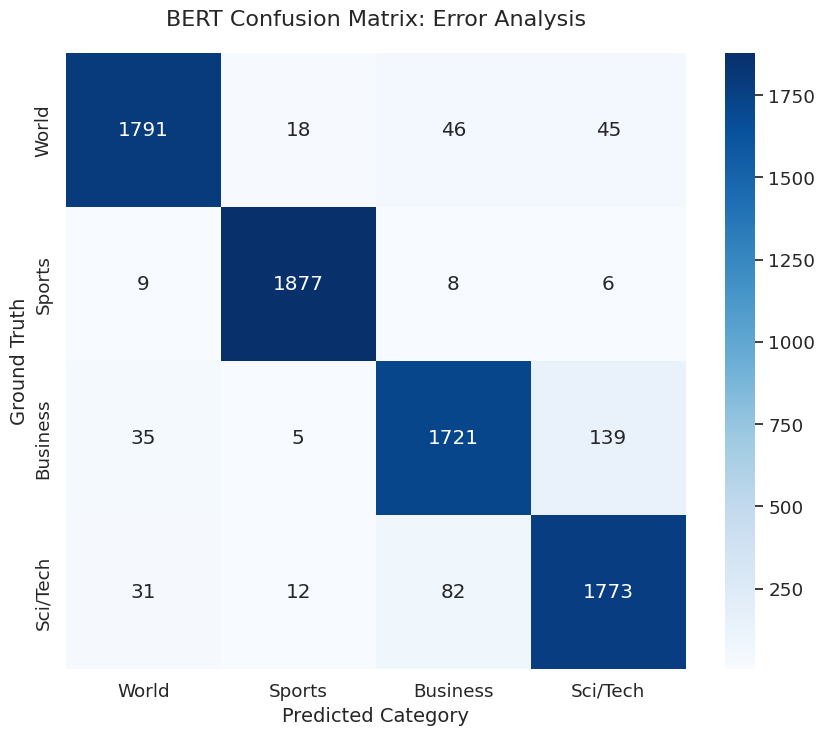

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('BERT Confusion Matrix: Error Analysis', fontsize=16, pad=20)
plt.ylabel('Ground Truth', fontsize=14)
plt.xlabel('Predicted Category', fontsize=14)
plt.show()

In [49]:
error_list = []
model.eval()

# Converting to list for easy indexing
raw_test_list = test_texts.tolist()

with torch.no_grad():
    current_pos = 0 
    
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = inputs["labels"].cpu().numpy()
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                error_list.append({
                    "True_Label": class_names[labels[i]],
                    "BERT_Prediction": class_names[preds[i]],
                    "Full_Text_Sample": raw_test_list[current_pos + i]
                })
            
            if len(error_list) >= 100: break
        
        current_pos += len(labels)
        if len(error_list) >= 100: break

for i, err in enumerate(error_list[:100]):
    print(f"--- Error #{i+1} ---")
    print(f"CORRECT: {err['True_Label']} | BERT SAID: {err['BERT_Prediction']}")
    print(f"TEXT: {err['Full_Text_Sample']}")
    print("-" * 60)

--- Error #1 ---
CORRECT: Sci/Tech | BERT SAID: Sports
TEXT: Promoting a Shared Vision [SEP] As Michael Kaleko kept running into people who were getting older and having more vision problems, he realized he could do something about it.
------------------------------------------------------------
--- Error #2 ---
CORRECT: World | BERT SAID: Sports
TEXT: Live: Olympics day four [SEP] Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.
------------------------------------------------------------
--- Error #3 ---
CORRECT: Business | BERT SAID: Sci/Tech
TEXT: Intel to delay product aimed for high-definition TVs [SEP] SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the launch of a video display chip it had previously planned to introduce by year end, putting off a showdown with Texas Instruments Inc. in the fast-growing market for high-definition television displays.
---------------------------------------------

## After counting the errors above here are my findings

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

error_data = {
    "Category": [
        "Class Overlap", 
        "Keyword Bias", 
        "Wrong Label", 
        "Label Noise",
        "Truncation"
    ],
    "Count": [52, 20, 20, 7, 1]
}

df_analysis = pd.DataFrame(error_data)

# Calculating percentage to show the 'Ceiling' of improvement
df_analysis['Error_Percentage'] = (df_analysis['Count'] / df_analysis['Count'].sum()) * 100

print("Aproximate Analysis")
print(df_analysis)

Aproximate Analysis
        Category  Count  Error_Percentage
0  Class Overlap     52              52.0
1   Keyword Bias     20              20.0
2    Wrong Label     20              20.0
3    Label Noise      7               7.0
4     Truncation      1               1.0


## Here is the breakdown of Class Overlap

In [51]:
error_data = {
    "Category": [
        "Business and Sci/Tech Overlap", 
        "Business and World Overlap", 
        "Business and Sports Overlap", 
        "World and Sci/Tech Overlap"
    ],
    "Count": [38, 9, 3, 2]
}

df_analysis = pd.DataFrame(error_data)

# Calculating percentage to show the 'Ceiling' of improvement
df_analysis['Error_Percentage'] = (df_analysis['Count'] / df_analysis['Count'].sum()) * 100

print("Evaluation Matrix")
print(df_analysis)

Evaluation Matrix
                        Category  Count  Error_Percentage
0  Business and Sci/Tech Overlap     38         73.076923
1     Business and World Overlap      9         17.307692
2    Business and Sports Overlap      3          5.769231
3     World and Sci/Tech Overlap      2          3.846154


---
# Mitigation Strategy
Based on error analysis, the mitigation strategy addresses:
1. **Keyword Bias** - Entity masking + keyword dropout
2. **Class Overlap** - Label smoothing for ambiguous boundaries
3. **Overfitting** - Regularization (dropout, weight decay, layer freezing, early stopping)

## 1. Keyword Bias Mitigation - Entity Masking & Keyword Dropout

In [52]:
import re

TECH_COMPANIES = {
    "intel", "cisco", "ibm", "hp", "hewlett-packard", "microsoft", "yahoo", 
    "amazon", "google", "apple", "dell", "oracle", "sun", "acer", "nokia",
    "motorola", "samsung", "sony", "tivo", "realnetworks", "red hat", "veritas",
    "siemens", "worldcom", "telstra", "hyundai", "caterpillar", "boeing"
}

FINANCIAL_TRIGGERS = {
    "acquires", "acquired", "acquisition", "buys", "bought", "purchase",
    "merger", "deal", "contract", "profit", "loss", "revenue", "earnings",
    "quarterly", "fiscal", "shares", "stock", "trading", "investor", "ipo",
    "billion", "million", "prices", "pricing", "cost", "sales", "market"
}

TECH_TRIGGERS = {
    "chip", "semiconductor", "software", "hardware", "processor", "server",
    "network", "wireless", "mobile", "cellphone", "broadband", "internet",
    "digital", "computing", "database", "algorithm"
}

In [53]:
def mask_text(text, mask_prob=0.15):
    text_lower = text.lower()
    
    for company in TECH_COMPANIES:
        pattern = re.compile(re.escape(company), re.IGNORECASE)
        text = pattern.sub("[ORG]", text)
    
    words = text.split()
    masked_words = []
    
    for word in words:
        clean = re.sub(r'[^\w]', '', word.lower())
        
        if clean in FINANCIAL_TRIGGERS or clean in TECH_TRIGGERS:
            if random.random() < mask_prob:
                masked_words.append("[MASK]")
            else:
                masked_words.append(word)
        else:
            masked_words.append(word)
    
    return " ".join(masked_words)

In [54]:
train_df["text_masked"] = train_df["text"].apply(lambda x: mask_text(x, mask_prob=0.15))

In [55]:
train_texts_masked = train_df["text_masked"]

train_encodings = tokenizer(
    train_texts_masked.tolist(),
    truncation=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    max_length=MAX_LEN
)

In [56]:
train_df.head(10)

,Class Index,Title,Description,text,word_len,text_masked
0,0,"Court looks at dogs, drugs, privacy (USATODAY....","USATODAY.com - Wednesday, the U.S. Supreme Cou...","Court looks at dogs, drugs, privacy (USATODAY....",39,"Court looks at dogs, drugs, privacy (USATODAY...."
1,0,"After Chaotic Procession, Arafat Is Laid to Re...",Yasir Arafat was laid to rest in a marble-and-...,"After Chaotic Procession, Arafat Is Laid to Re...",41,"After Chaotic Procession, Arafat Is Laid to Re..."
2,0,Israel split over E Jerusalem residents partic...,"Jerusalem, Nov 14 : Israel is divided over a U...",Israel split over E Jerusalem residents partic...,42,Israel split over E Jerusalem residents partic...
3,0,Musharraf not decided on quitting army post: US,WASHINGTON: The United States says that Pakist...,Musharraf not decided on quitting army post: U...,40,Musharraf not decided on quitting army post: U...
4,0,Abbas Wins Backing of Brigades,"GAZA CITY, 29 November 2004 - Palestine Libera...",Abbas Wins Backing of Brigades [SEP] GAZA CITY...,43,Abbas Wins Backing of Brigades [SEP] GAZA CITY...
5,0,Somalia to get new parliament,Somalia's first parliament for 13 years is exp...,Somalia to get new parliament [SEP] Somalia's ...,24,Somalia to get new parliament [SEP] Somalia's ...
6,0,Japan Considers Sanctions Vs. N. Korea (AP),AP - Japan on Tuesday warned it would consider...,Japan Considers Sanctions Vs. N. Korea (AP) [S...,40,Japan Considers Sanctions Vs. N. Korea (AP) [S...
7,0,"Iraq bombings kill 8, including US soldier",Four coalition and Iraqi military convoys and ...,"Iraq bombings kill 8, including US soldier [SE...",39,"Iraq bombings kill 8, including US soldier [SE..."
8,0,Tripoli summit rejects intervention in Darfur,"In conclusion of its works, the African summit...",Tripoli summit rejects intervention in Darfur ...,36,Tripoli summit rejects intervention in Darfur ...
9,0,Police underestimated Palm Island crisis,Queensland Police Commissioner Bob Atkinson ha...,Police underestimated Palm Island crisis [SEP]...,30,Police underestimated Palm Island crisis [SEP]...


In [57]:
train_df[train_df["Class Index"] == 3][["text", "text_masked"]].iloc[0]

text           Taipei goes Wi-Fi [SEP] The network will reach...
text_masked    Taipei goes Wi-Fi [SEP] The [MASK] will reach ...
Name: 87651, dtype: object

In [58]:
def get_dataset_item(encodings, labels, idx):
    item = {k: torch.tensor(v[idx]) for k, v in encodings.items()}
    item["labels"] = torch.tensor(labels[idx])
    return item

def create_dataset(encodings, labels):
    labels_list = labels.tolist()
    
    class MaskedDataset(torch.utils.data.Dataset):
        def __init__(self):
            pass
        def __getitem__(self, idx):
            return get_dataset_item(encodings, labels_list, idx)
        def __len__(self):
            return len(labels_list)
    
    return MaskedDataset()

train_dataset = create_dataset(train_encodings, train_labels)
test_dataset = create_dataset(test_encodings, test_labels)

In [59]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=data_collator, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=data_collator, num_workers=4, pin_memory=True)

In [60]:
def label_smoothing_loss(logits, labels, num_classes=4, smoothing=0.15):
    confidence = 1.0 - smoothing
    smooth_labels = torch.full_like(logits, smoothing / (num_classes - 1))
    smooth_labels.scatter_(1, labels.unsqueeze(1), confidence)
    log_probs = torch.nn.functional.log_softmax(logits, dim=1)
    return -(smooth_labels * log_probs).sum(dim=1).mean()

In [62]:
from transformers import AutoModelForSequenceClassification, AutoConfig
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = AutoConfig.from_pretrained(
    "bert-base-uncased", 
    num_labels=4 
)
config.hidden_dropout_prob = 0.3
config.attention_probs_dropout_prob = 0.2
config.classifier_dropout = 0.4

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    config=config
)

for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for i in range(6):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [63]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.05)

num_training_steps = len(train_loader) * 5
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0.1 * num_training_steps,
    num_training_steps=num_training_steps
)

In [64]:
from torch.amp import autocast, GradScaler
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import gc

train_writer = SummaryWriter("runs/regularized_training")

scaler = GradScaler('cuda')
global_step = 0
EPOCHS = 5
ACCUMULATION_STEPS = 2
best_loss = float('inf')
patience_counter = 0
PATIENCE = 2

print(f"Starting training...")
print(f"GPU Memory before: {torch.cuda.memory_allocated()/1024**3:.2f}GB")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    epoch_preds = []
    epoch_labels = []
    loop = tqdm(train_loader, leave=True)
    optimizer.zero_grad()
    
    for batch_idx, batch in enumerate(loop):
        batch = {k: v.to(device) for k, v in batch.items()}

        with autocast('cuda'):
            outputs = model(**batch)
            loss = label_smoothing_loss(outputs.logits, batch["labels"], num_classes=4, smoothing=0.15)
            loss = loss / ACCUMULATION_STEPS

        preds = torch.argmax(outputs.logits, dim=1)
        epoch_preds.extend(preds.cpu().numpy())
        epoch_labels.extend(batch["labels"].cpu().numpy())
        
        batch_acc = (preds == batch["labels"]).float().mean().item()

        scaler.scale(loss).backward()
        
        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            
            train_writer.add_scalar("Train/Loss", loss.item() * ACCUMULATION_STEPS, global_step)
            train_writer.add_scalar("Train/LR", scheduler.get_last_lr()[0], global_step)
            train_writer.add_scalar("Train/Batch_Accuracy", batch_acc, global_step)

        total_loss += loss.item() * ACCUMULATION_STEPS
        global_step += 1
        
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item() * ACCUMULATION_STEPS, acc=f"{batch_acc:.3f}")

    avg_loss = total_loss / len(train_loader)
    epoch_acc = sum(p == l for p, l in zip(epoch_preds, epoch_labels)) / len(epoch_labels)
    epoch_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    
    train_writer.add_scalar("Epoch/Avg_Train_Loss", avg_loss, epoch)
    train_writer.add_scalar("Epoch/Accuracy", epoch_acc, epoch)
    train_writer.add_scalar("Epoch/F1_Macro", epoch_f1, epoch)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        train_writer.add_scalar("Epoch/Best_Loss", best_loss, epoch)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

train_writer.flush()
train_writer.close()

del epoch_preds, epoch_labels, scaler
gc.collect()
torch.cuda.empty_cache()

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
print(f"\nTraining complete. Best model loaded.")
print(f"GPU Memory after: {torch.cuda.memory_allocated()/1024**3:.2f}GB")

Starting training...
GPU Memory before: 1.24GB


  0%|          | 0/7305 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.8574 | Acc: 0.8112 | F1: 0.8100


  0%|          | 0/7305 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.7188 | Acc: 0.9177 | F1: 0.9176


...

Epoch 3 | Loss: 0.7019 | Acc: 0.9277 | F1: 0.9277


  0%|          | 0/7305 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.6902 | Acc: 0.9346 | F1: 0.9346


  0%|          | 0/7305 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.6828 | Acc: 0.9397 | F1: 0.9397

Training complete. Best model loaded.
GPU Memory after: 1.73GB


In [ ]:
import gc
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

torch.cuda.empty_cache()
gc.collect()

print("="*60)
print("FINAL MODEL EVALUATION - STARTING")
print("="*60)

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        with torch.cuda.amp.autocast():
            outputs = model(**batch)
        
        preds = torch.argmax(outputs.logits, dim=1)
        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(batch["labels"].cpu().numpy())

correct = (np.array(all_predictions) == np.array(all_true_labels)).sum()
total = len(all_true_labels)

print(f"\n{'='*60}")
print(f"FINAL MODEL RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {correct/total:.4f} ({correct}/{total})")
print(f"{'='*60}\n")

print("Classification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=class_names))

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)', fontsize=14)
plt.ylabel('Ground Truth')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

del all_predictions, all_true_labels
gc.collect()
torch.cuda.empty_cache()